# Explore AAUWSS Data

## Overview

[Aalborg University Wearable Sleep Study (AAUWSS)](https://zenodo.org/records/16919071) / [GitHub - sdjanian/sf_sleep](https://github.com/sdjanian/sf_sleep):
- publicly available dataset for sleep studies.
- contains both PPG and ECG data.
- during sleep, which is what we need to compare with the smartwatch.

> My modified notes about the dataset

`aligned_sleep_data_set/`
- Contains the ECG and PPG recordings synchronized and aligned with their respective sleep stage labels.
- The files are stored as a pickle file where each row is a 30 second sleep epoch.
- The columns correspond to the samples
    - **ECG** files are 30*200Hz (6000) columns
    - **PPG** files are 30*64 Hz (1920) columns.
    - Also there are additional metadata columns.
- Subject 12 and 13 had their PSGs reboots during their overnight stay, which is why they have multiple .edf files. In the aligned dataset these have been stitched together into one continuous file denoting the missing segments.

## Code & Helpers

In [48]:
import pickle
from pathlib import Path
from typing import Any, Literal

import numpy as np
import plotly.graph_objects as go
import pandas as pd
from IPython.display import Image, Markdown, display
from plotly.subplots import make_subplots
from scipy.signal import butter, filtfilt


from avtsoof.common_utils import data_dir, DOCS

In [49]:
# Constants

# sampling rates (Hz)
ECG_FS = 200
PPG_FS = 64

# Paths
ASSETS_DIR_PATH = Path("assets")


In [50]:
# Helpers

def save_and_link(fig, name: str, height: int = 700):
    ASSETS_DIR_PATH.mkdir(exist_ok=True)
    out = ASSETS_DIR_PATH / f"{name}.html"
    fig.write_html(out, include_plotlyjs="cdn", full_html=True)
    png_path = ASSETS_DIR_PATH / f"{name}.png"
    fig.write_image(png_path, height=height)
    display(Image(filename=png_path))
    display(Markdown(f"[▶ Open interactive **{name}**]({out.as_posix()})"))

## Load and Aggregate Data

Lets select a single subject to view theirs data

In [51]:
ecg_example_path = data_dir("AAUWSS") / "aligned_sleep_data_set" / "ecg" / "subject_01_ecg.pkl"
assert ecg_example_path.exists(), f"Missing {ecg_example_path}"

In [52]:
ppg_example_path = data_dir("AAUWSS") / "aligned_sleep_data_set" / "ppg" / "subject_01_ppg.pkl"
assert ppg_example_path.exists(), f"Missing {ppg_example_path}"

In [53]:
with open(ecg_example_path, "rb") as f:
    ecg_data = pickle.load(f)

C:\Users\TSOOF\AppData\Local\Temp\1\ipykernel_30832\494588992.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  ecg_data = pickle.load(f)


In [54]:
with open(ppg_example_path, "rb") as f:
    ppg_data = pickle.load(f)

C:\Users\TSOOF\AppData\Local\Temp\1\ipykernel_30832\2006652815.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  ppg_data = pickle.load(f)


In [55]:
print(ecg_data.columns)

Index([       0,        1,        2,        3,        4,        5,        6,
              7,        8,        9,
       ...
           5993,     5994,     5995,     5996,     5997,     5998,     5999,
       'labels',  'epoch',   'time'],
      dtype='object', length=6003)


In [56]:
METADATA_COLUMNS = {'labels',  'epoch',   'time'}

In [57]:
print(ecg_data["labels"].unique())

['Wake' 'N1' 'N2' 'N3' 'REM']


In [58]:
LABELS_SLEEP_STAGES = {'N1', 'N2', 'N3', 'REM'}

In [59]:
ecg_data

,0,1,2,3,4,5,6,7,8,9,...,5993,5994,5995,5996,5997,5998,5999,labels,epoch,time
0,6394.477706,6602.352611,7556.085788,8093.290597,7954.707327,7315.511460,6146.117801,5579.327799,5654.069338,5650.955107,...,6545.517899,6557.196265,6575.103092,6600.795495,6615.588092,6630.380688,6656.073092,Wake,1.0,"[2023-03-24T23:32:00.000000000, 2023-03-24T23:..."
1,6685.658284,6709.015015,6733.928861,6773.635304,6814.120304,6849.155400,6877.962035,6915.332804,6966.717612,7007.981170,...,6662.301553,6663.080111,6657.630207,6654.515976,6661.522996,6664.637226,6659.187323,Wake,2.0,"[2023-03-24T23:32:30.000000000, 2023-03-24T23:..."
2,6654.515976,6657.630207,6659.187323,6655.294534,6656.851650,6659.187323,6658.408765,6656.073092,6652.180303,6656.851650,...,6499.582995,6505.032899,6497.247322,6492.575976,6497.247322,6498.025880,6498.025880,Wake,3.0,"[2023-03-24T23:33:00.000000000, 2023-03-24T23:..."
3,6492.575976,6491.797418,6493.354534,6494.911649,6487.904630,6486.347514,6494.911649,6489.461745,6484.011841,6484.790399,...,6876.404920,6874.847804,6875.626362,6872.512131,6871.733573,6877.183477,6870.955016,Wake,4.0,"[2023-03-24T23:33:30.000000000, 2023-03-24T23:..."
4,6870.176458,6874.847804,6874.069246,6879.519150,6878.740593,6873.290689,6878.740593,6876.404920,6873.290689,6878.740593,...,6564.203284,6557.974822,6556.417707,6560.310495,6559.531938,6557.196265,6563.424726,Wake,5.0,"[2023-03-24T23:34:00.000000000, 2023-03-24T23:..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,1245.875668,1225.633168,1216.290475,1234.197302,1241.204321,1220.183264,1209.283456,1226.411725,1238.090091,1214.733360,...,556.073550,549.066530,570.087588,570.087588,544.395184,535.831050,554.516434,N1,841.0,"[2023-03-25T06:32:00.000000000, 2023-03-25T06:..."
841,558.409223,532.716819,528.045473,549.845088,548.287973,525.709799,521.817011,541.280953,542.838069,518.702780,...,101.395856,78.039125,65.582202,88.938932,95.945952,73.367779,67.917875,Wake,842.0,"[2023-03-25T06:32:30.000000000, 2023-03-25T06:..."
842,89.717490,99.060183,79.596240,71.810663,93.610279,102.174413,81.153356,69.474990,89.717490,99.838740,...,-371.967223,-348.610492,-350.946165,-374.302896,-369.631550,-346.274819,-354.060396,Wake,843.0,"[2023-03-25T06:33:00.000000000, 2023-03-25T06:..."
843,-378.974242,-371.967223,-350.946165,-357.174627,-376.638569,-373.524339,-347.831935,-352.503281,-377.417127,-369.631550,...,-306.568377,-301.118473,-320.582415,-335.375011,-315.911069,-303.454146,-329.146550,N1,844.0,"[2023-03-25T06:33:30.000000000, 2023-03-25T06:..."


In [60]:
ppg_data

,0,1,2,3,4,5,6,7,8,9,...,1913,1914,1915,1916,1917,1918,1919,labels,epoch,time
0,-224.67,-252.08,-278.37,-305.43,-332.21,-354.84,-368.84,-371.87,-364.97,-352.20,...,12.45,13.60,14.92,16.02,16.72,16.96,16.90,Wake,1.0,"[2023-03-24T23:32:00.000000000, 2023-03-24T23:..."
1,16.73,16.60,16.55,16.54,16.53,16.47,16.39,16.28,16.23,16.25,...,7.61,5.87,4.38,3.04,1.70,0.24,-1.42,Wake,2.0,"[2023-03-24T23:32:30.000000000, 2023-03-24T23:..."
2,-3.26,-5.22,-7.25,-9.39,-11.62,-14.07,-16.80,-19.84,-23.21,-26.94,...,7.81,5.11,2.68,0.47,-1.55,-3.42,-5.18,Wake,3.0,"[2023-03-24T23:33:00.000000000, 2023-03-24T23:..."
3,-6.97,-8.96,-11.38,-14.34,-17.81,-21.52,-25.08,-28.14,-30.57,-32.62,...,-38.35,-41.93,-43.72,-45.12,-46.87,-49.40,-53.00,Wake,4.0,"[2023-03-24T23:33:30.000000000, 2023-03-24T23:..."
4,-58.01,-64.80,-73.58,-84.33,-96.65,-109.92,-123.33,-136.04,-147.23,-156.18,...,-17.51,-19.18,-21.04,-23.15,-25.50,-28.00,-30.57,Wake,5.0,"[2023-03-24T23:34:00.000000000, 2023-03-24T23:..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,31.28,30.51,29.84,29.47,29.56,30.19,31.31,32.80,34.42,35.88,...,32.53,30.69,28.79,26.88,24.99,23.08,21.06,N1,841.0,"[2023-03-25T06:32:00.000000000, 2023-03-25T06:..."
841,18.89,16.57,14.16,11.77,9.48,7.36,5.43,3.65,1.96,0.28,...,30.06,27.87,25.60,23.24,20.80,18.34,15.94,Wake,842.0,"[2023-03-25T06:32:30.000000000, 2023-03-25T06:..."
842,13.70,11.71,9.93,8.26,6.61,4.87,2.97,0.90,-1.33,-3.68,...,36.74,34.99,33.60,32.83,32.81,33.48,34.69,Wake,843.0,"[2023-03-25T06:33:00.000000000, 2023-03-25T06:..."
843,36.21,37.79,39.15,40.06,40.34,39.87,38.67,36.85,34.58,32.05,...,30.20,31.76,33.15,34.13,34.64,34.65,34.19,N1,844.0,"[2023-03-25T06:33:30.000000000, 2023-03-25T06:..."


We can see that ecg and ppg has different scales

In [61]:
# filter out metadata columns
ecg_data_pure = ecg_data.drop(columns=METADATA_COLUMNS)
ppg_data_pure = ppg_data.drop(columns=METADATA_COLUMNS)


In [62]:
ecg_data_pure.shape, ppg_data_pure.shape

((845, 6000), (845, 1920))

The length of the data is different, which is expected since the sampling rate of the two devices are different.

We will need to take that into account when comparing the two signals. 

In [63]:
# merge all rows into a single series
ecg_series = ecg_data_pure.stack()
ppg_series = ppg_data_pure.stack()

In [64]:
def get_stats(series: pd.Series) -> pd.DataFrame:
    stats = series.agg(["mean", "std", "min", "max", "shape"]).to_frame().T
    return stats

In [65]:
ecg_stats = get_stats(ecg_series)
ppg_stats = get_stats(ppg_series)

print(ecg_stats)
print(ppg_stats)

          mean        std          min           max       shape
0  2584.445783  1607.1741 -2400.110019  10360.450606  (5070000,)
       mean        std     min      max       shape
0 -0.000577  68.777211 -1129.1  1335.18  (1622400,)


In [66]:
# to numpy arrays for further processing
ecg_arr = ecg_series.to_numpy(dtype=float)
ppg_arr = ppg_series.to_numpy(dtype=float)

# Build time axes from sampling rate
t_ecg = np.arange(ecg_arr.size) / ECG_FS
t_ppg = np.arange(ppg_arr.size) / PPG_FS

print("sanity check: both should represent nearly same total duration")
print("ECG duration (s):", t_ecg[-1])
print("PPG duration (s):", t_ppg[-1])
assert np.isclose(t_ecg[-1], t_ppg[-1], rtol=0.01), "ECG and PPG durations are not close enough"

sanity check: both should represent nearly same total duration
ECG duration (s): 25349.995
PPG duration (s): 25349.984375


## Visualize

In [67]:
def plot_signal(signal_arr,
                fs: int,
                title: str,
                start_sec: int | None = None,
                end_sec: int | None = None,
                focus: Literal["crop", "zoom"] = "crop",
):
    t_signal = np.arange(signal_arr.size) / fs
    
    # Crop the signal to the requested window
    if focus == "crop" and start_sec is not None and end_sec is not None:
        mask = (t_signal >= start_sec) & (t_signal <= end_sec)
        t_signal = t_signal[mask]
        signal_arr = signal_arr[mask]

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(x=t_signal, y=signal_arr, name=title, line=dict(width=1))
    )

    fig.update_layout(
        height=400,
        template="plotly_white",
        hovermode="x unified",
        title=title
    )
    fig.update_xaxes(title_text="Time (s)")
    fig.update_yaxes(title_text="Amplitude")

    # Zoom the view without dropping data
    if focus == "zoom" and start_sec is not None and end_sec is not None:
        fig.update_xaxes(range=[start_sec, end_sec])

    save_and_link(fig, title.replace(" ", "_").lower())

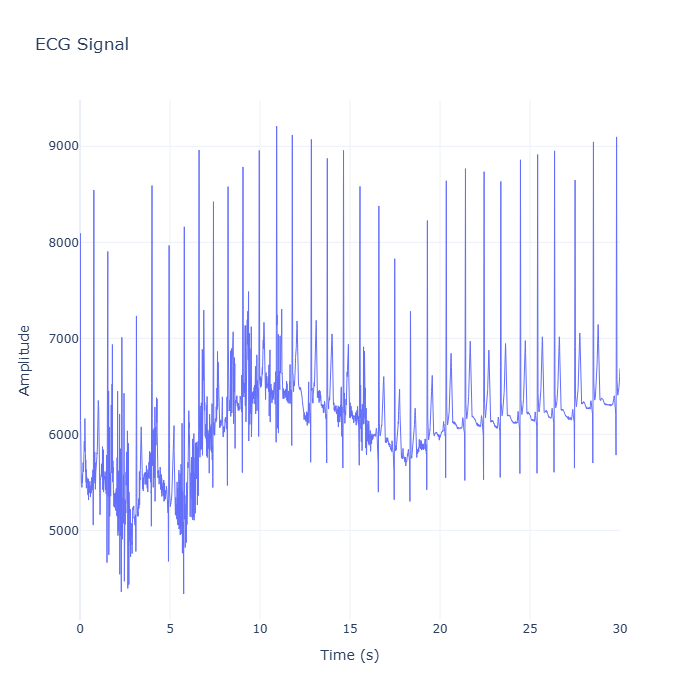

[▶ Open interactive **ecg_signal**](assets/ecg_signal.html)

In [68]:
plot_signal(ecg_arr, fs=ECG_FS, title="ECG Signal", start_sec=0, end_sec=30)

In [69]:
def plot_synced_signals(ecg_arr,
                        ppg_arr,
                        title: str,
                        start_sec: int | None = None,
                        end_sec: int | None = None,
                        focus: Literal["crop", "zoom"] = "crop",
                        ):
    """
    Plot ECG and PPG signals in sync, optionally zoomed into a specific time range.
    """
    # Build time axes from sampling rate
    t_ecg = np.arange(ecg_arr.size) / ECG_FS
    t_ppg = np.arange(ppg_arr.size) / PPG_FS

    if focus == "crop" and start_sec is not None and end_sec is not None:
        # Crop the signals to the requested window
        mask_ecg = (t_ecg >= start_sec) & (t_ecg <= end_sec)
        mask_ppg = (t_ppg >= start_sec) & (t_ppg <= end_sec)
        t_ecg = t_ecg[mask_ecg]
        ecg_arr = ecg_arr[mask_ecg]
        t_ppg = t_ppg[mask_ppg]
        ppg_arr = ppg_arr[mask_ppg]

    # Create subplots
    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.06,
        subplot_titles=("ECG (200 Hz)", "PPG (64 Hz)")
    )

    fig.add_trace(
        go.Scatter(x=t_ecg, y=ecg_arr, name="ECG", line=dict(color="mediumseagreen", width=1)),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=t_ppg, y=ppg_arr, name="PPG", line=dict(color="crimson", width=1)),
        row=2, col=1
    )

    fig.update_layout(
        height=700,
        template="plotly_white",
        hovermode="x unified",
        showlegend=False
    )
    fig.update_xaxes(title_text="Time (s)", row=2, col=1)
    fig.update_yaxes(title_text="Amplitude", row=1, col=1)
    fig.update_yaxes(title_text="Amplitude", row=2, col=1)

    # Zoom the view without dropping data
    if focus == "zoom" and start_sec is not None and end_sec is not None:
        fig.update_xaxes(range=[start_sec, end_sec])

    save_and_link(fig, title.replace(" ", "_").lower())

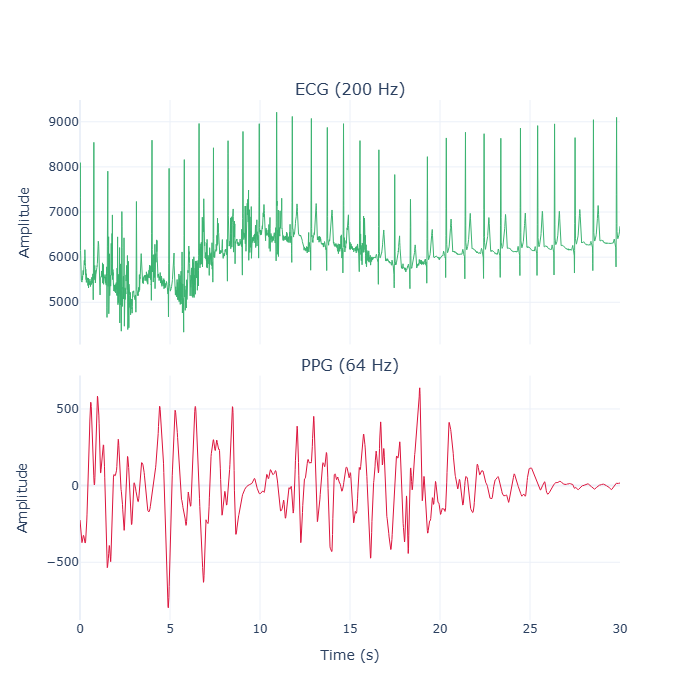

[▶ Open interactive **synced_signals**](assets/synced_signals.html)

In [70]:
plot_synced_signals(ecg_arr, ppg_arr, title="Synced Signals", start_sec=0, end_sec=30)

## Extract Simple Heart Beat

Focusing on the first 30 seconds lets find the heart beats in both signals and compare them.

`np.fft.rfft` is a function that computes the one-dimensional n-point discrete Fourier Transform (DFT) and its inverse. It is used to analyze the frequency components of a signal.

In [71]:
def calc_dominant_freq(signal: np.ndarray, fs: int) -> float:
    fft_result = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(len(signal), d=1/fs)
    dominant_index = np.argmax(np.abs(fft_result))
    return freqs[dominant_index]

In [72]:
heartbeat_freq_ecg = calc_dominant_freq(ecg_arr, ECG_FS)
heartbeat_freq_ecg

np.float64(0.0)

We get 0 because the signal has a DC component (i.e. the average value of the signal is not zero). The DC component corresponds to the 0 Hz frequency in the Fourier Transform.


In [73]:
def plot_fft_signal(signal, fs, title):
    fft_result = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(len(signal), d=1/fs)
    magnitude = np.abs(fft_result)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=freqs, y=magnitude, mode='lines', name='FFT Magnitude'))
    fig.update_layout(title=title, xaxis_title='Frequency (Hz)', yaxis_title='Magnitude')
    save_and_link(fig, title.replace(" ", "_").lower())

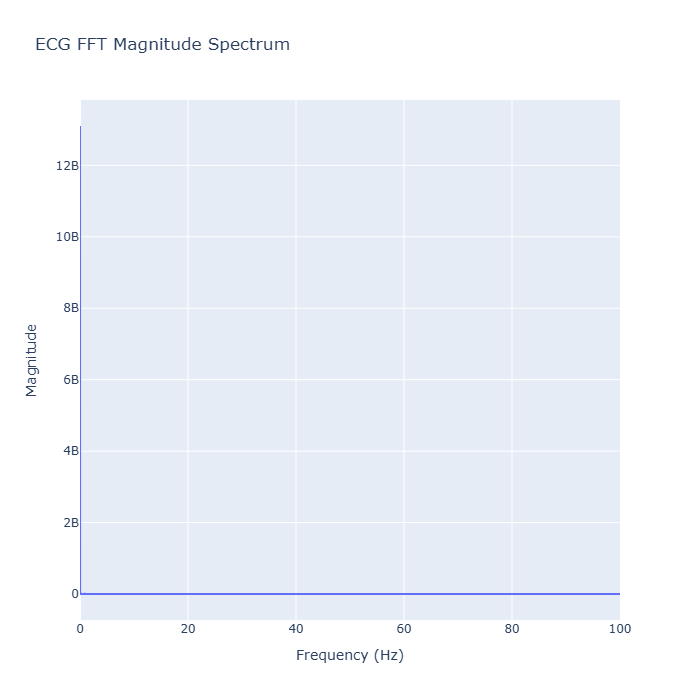

[▶ Open interactive **ecg_fft_magnitude_spectrum**](assets/ecg_fft_magnitude_spectrum.html)

In [74]:
plot_fft_signal(ecg_arr, ECG_FS, title="ECG FFT Magnitude Spectrum")


So we need to apply a high-pass filter to remove the DC component and focus on the AC component of the signal.

In [75]:
def high_pass_filter(signal: np.ndarray, fs: int, cutoff_freq: float = 1.0) -> np.ndarray:
    """
    Apply a high-pass filter to the signal to remove low-frequency components.
    """
    # Design a Butterworth high-pass filter
    b, a = butter(N=4, Wn=cutoff_freq / (0.5 * fs), btype='high', analog=False)
    
    # Apply the filter to the signal
    filtered_signal = filtfilt(b, a, signal)
   
    return filtered_signal

In [76]:
ecg_arr_ac = high_pass_filter(ecg_arr, ECG_FS, cutoff_freq=10.0)
ppg_arr_ac = high_pass_filter(ppg_arr, PPG_FS, cutoff_freq=10.0)

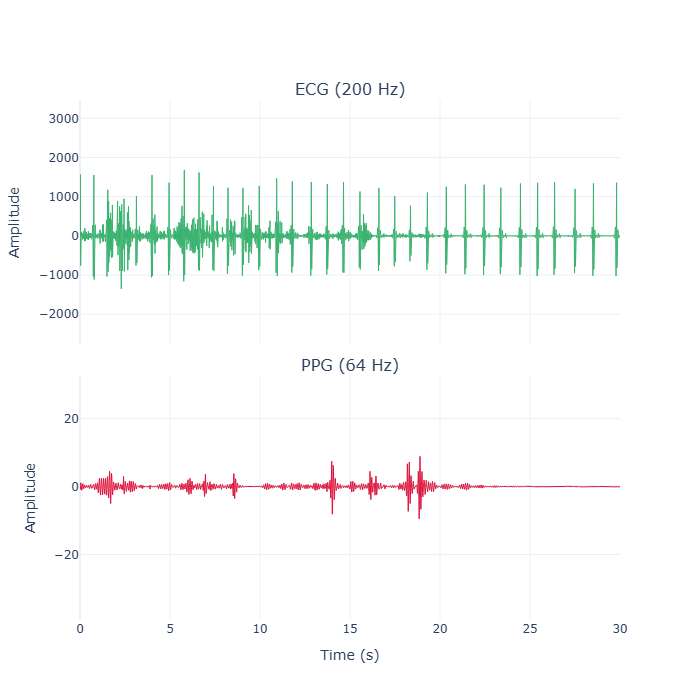

[▶ Open interactive **synced_signals_(ac_component_-_fc=10hz)**](assets/synced_signals_(ac_component_-_fc=10hz).html)

In [77]:
plot_synced_signals(ecg_arr_ac, ppg_arr_ac, title="Synced Signals (AC Component - fc=10Hz)", start_sec=0, end_sec=30, focus="zoom")

In [78]:
heartbeat_freq_ecg = calc_dominant_freq(ecg_arr_ac, ECG_FS)
heartbeat_freq_ppg = calc_dominant_freq(ppg_arr_ac, PPG_FS)
heartbeat_freq_ecg, heartbeat_freq_ppg

(np.float64(13.482287968441813), np.float64(7.999999999999999))

Still not good, lets try to visualize the FFT to understand why

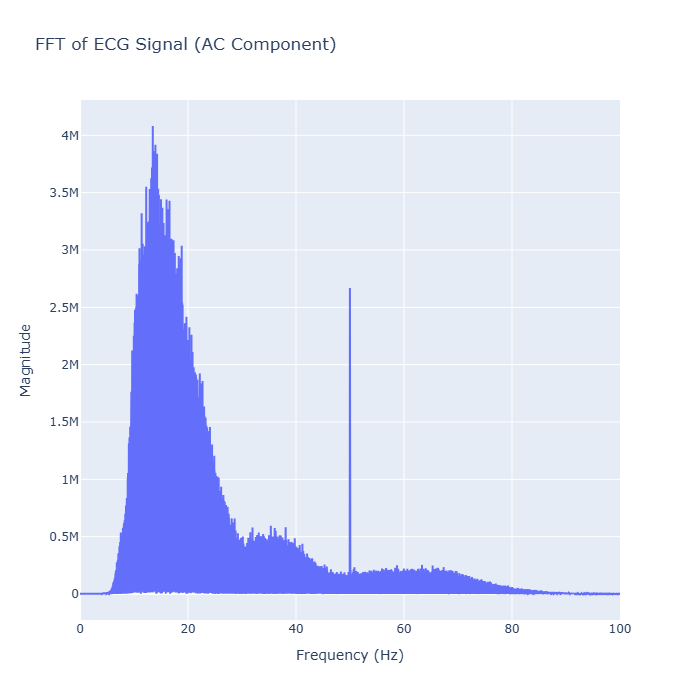

[▶ Open interactive **fft_of_ecg_signal_(ac_component)**](assets/fft_of_ecg_signal_(ac_component).html)

In [79]:

plot_fft_signal(ecg_arr_ac, ECG_FS, title="FFT of ECG Signal (AC Component)")

we can see that the dominant frequency is indeed at around 50Hz but still there is a lot of noise in the lower bound

In [80]:
ecg_arr_ac = high_pass_filter(ecg_arr, ECG_FS, cutoff_freq=30.0)
ppg_arr_ac = high_pass_filter(ppg_arr, PPG_FS, cutoff_freq=30.0)

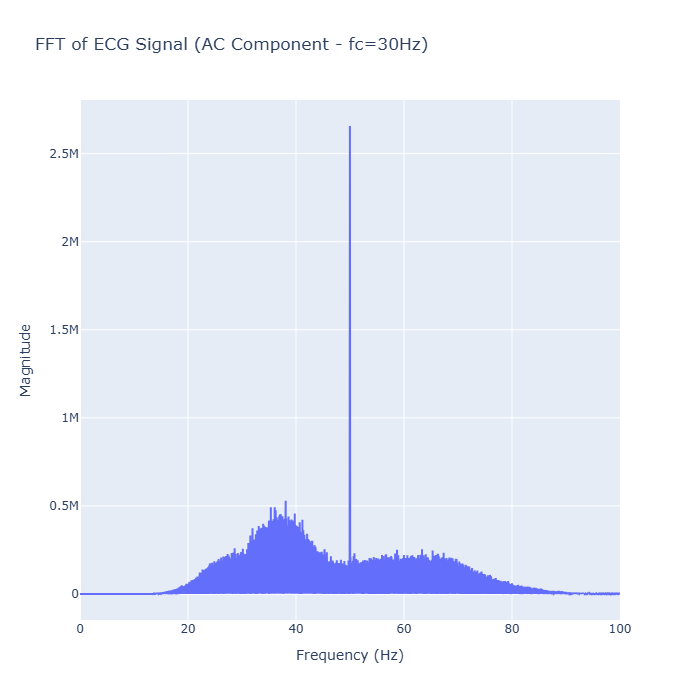

[▶ Open interactive **fft_of_ecg_signal_(ac_component_-_fc=30hz)**](assets/fft_of_ecg_signal_(ac_component_-_fc=30hz).html)

In [81]:
plot_fft_signal(ecg_arr_ac, ECG_FS, title="FFT of ECG Signal (AC Component - fc=30Hz)")

Much better!

In [82]:
heartbeat_freq_ecg = calc_dominant_freq(ecg_arr_ac, ECG_FS)
heartbeat_freq_ppg = calc_dominant_freq(ppg_arr_ac, PPG_FS)
heartbeat_freq_ecg, heartbeat_freq_ppg

(np.float64(49.98307692307692), np.float64(31.11644970414201))

What about the PPG signal?

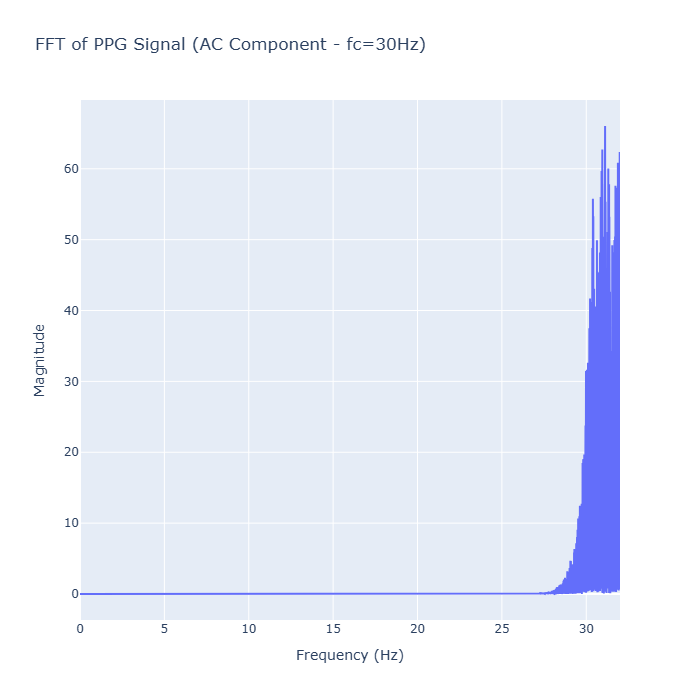

[▶ Open interactive **fft_of_ppg_signal_(ac_component_-_fc=30hz)**](assets/fft_of_ppg_signal_(ac_component_-_fc=30hz).html)

In [83]:
plot_fft_signal(ppg_arr_ac, PPG_FS, title="FFT of PPG Signal (AC Component - fc=30Hz)")